Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

SQL Server (SSMS) - Step 1: Create database + table

- Mo SSMS, ket noi den server.
- Tao database moi: `BankChurn`.
- Tao bang `dbo.bank_churn` bang script ben duoi.
- Luu y: hay chay toan bo script (dam bao co chu `C` trong `CREATE`).

```sql
USE master;
GO

CREATE DATABASE BankChurn;
GO

USE BankChurn;
GO

CREATE TABLE dbo.bank_churn (
    customer_id INT NOT NULL,
    country NVARCHAR(50) NOT NULL,
    gender NVARCHAR(10) NOT NULL,
    age INT NOT NULL,
    credit_score INT NOT NULL,
    balance FLOAT NOT NULL,
    products_number INT NOT NULL,
    credit_card INT NOT NULL,
    active_member INT NOT NULL,
    estimated_salary FLOAT NOT NULL,
    tenure INT NOT NULL,
    churn INT NOT NULL
);
```

- Buoc tiep theo: Import file CSV vao bang `dbo.bank_churn` bang "Import Flat File" trong SSMS.

SQL Server (SSMS) - Step 2: Import CSV vao bang

1) Mo SSMS, chon database `BankChurn`.
2) Chuot phai `Tasks` -> `Import Flat File...`.
3) File: chon `Bank Customer Churn Prediction.csv` trong thu muc workspace.
4) Ten bang: `dbo.bank_churn` (chon "Use existing table").
5) Kiem tra mapping cot, giu dung kieu du lieu va thu tu.
6) Finish.

Neu SSMS khong cho chon bang co san, lam theo cach nay:
- Import vao bang moi, vi du `dbo.bank_churn_raw`.
- Sau do chay lenh SQL de copy vao bang chuan:

```sql
INSERT INTO dbo.bank_churn (
    customer_id, country, gender, age, credit_score, balance,
    products_number, credit_card, active_member, estimated_salary,
    tenure, churn
)
SELECT
    customer_id, country, gender, age, credit_score, balance,
    products_number, credit_card, active_member, estimated_salary,
    tenure, churn
FROM dbo.bank_churn_raw;
```

Xac nhan import ok:
```sql
SELECT TOP 5 * FROM dbo.bank_churn;
SELECT COUNT(*) AS total_rows FROM dbo.bank_churn;
```

SQL Server (SSMS) - Step 3: Truy van EDA bang SQL

Chay cac truy van sau trong SSMS va luu ket qua (screenshot hoac copy vao report).

```sql
USE BankChurn;
GO

-- 1) Tong quan va ti le churn
SELECT
    COUNT(*) AS total_customers,
    AVG(CAST(churn AS FLOAT)) AS churn_rate
FROM dbo.bank_churn;

-- 2) Churn theo gender
SELECT
    gender,
    COUNT(*) AS n,
    AVG(CAST(churn AS FLOAT)) AS churn_rate
FROM dbo.bank_churn
GROUP BY gender
ORDER BY churn_rate DESC;

-- 3) Churn theo country
SELECT
    country,
    COUNT(*) AS n,
    AVG(CAST(churn AS FLOAT)) AS churn_rate
FROM dbo.bank_churn
GROUP BY country
ORDER BY churn_rate DESC;

-- 4) Churn theo active_member
SELECT
    active_member,
    COUNT(*) AS n,
    AVG(CAST(churn AS FLOAT)) AS churn_rate
FROM dbo.bank_churn
GROUP BY active_member
ORDER BY churn_rate DESC;

-- 5) Churn theo products_number
SELECT
    products_number,
    COUNT(*) AS n,
    AVG(CAST(churn AS FLOAT)) AS churn_rate
FROM dbo.bank_churn
GROUP BY products_number
ORDER BY products_number;

-- 6) Nhom tuoi
SELECT
    CASE
        WHEN age < 30 THEN 'under_30'
        WHEN age BETWEEN 30 AND 45 THEN '30_45'
        WHEN age BETWEEN 46 AND 60 THEN '46_60'
        ELSE 'over_60'
    END AS age_group,
    COUNT(*) AS n,
    AVG(CAST(churn AS FLOAT)) AS churn_rate
FROM dbo.bank_churn
GROUP BY CASE
    WHEN age < 30 THEN 'under_30'
    WHEN age BETWEEN 30 AND 45 THEN '30_45'
    WHEN age BETWEEN 46 AND 60 THEN '46_60'
    ELSE 'over_60'
END
ORDER BY churn_rate DESC;
```

Buoc tiep theo: quay lai notebook de lam EDA va ML bang Python nhu hien tai.

SQL Server (Python) - Step 4: Ket noi va doc du lieu tu SQL

Muc tieu: Doc bang `dbo.bank_churn` tu SQL Server vao pandas de chung minh pipeline SQL -> Python.

1) Cai goi ket noi (neu chua co):
   - Mo terminal (PowerShell) va chay:

```
pip install pyodbc
```

2) Cap nhat ten server trong cell duoi day (vi du: `localhost`, `DESKTOP-XXXX\\SQLEXPRESS`, ...).
3) Chay cell ket noi va doc du lieu.

In [ ]:
import pyodbc

server = "localhost"  # doi thanh ten server cua ban
# Vi du neu dung SQL Express: "DESKTOP-XXXX\\SQLEXPRESS"
database = "BankChurn"

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

with pyodbc.connect(conn_str) as conn:
    df_sql = pd.read_sql("SELECT * FROM dbo.bank_churn", conn)

df_sql.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_24836\3439163826.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql("SELECT * FROM dbo.bank_churn", conn)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.000000,1,True,True,101348.882812,True
1,15647311,608,Spain,Female,41,1,83807.859375,1,False,True,112542.578125,False
2,15619304,502,France,Female,42,8,159660.796875,3,True,False,113931.570312,True
3,15701354,699,France,Female,39,1,0.000000,2,False,False,93826.632812,False
4,15737888,850,Spain,Female,43,2,125510.820312,1,True,True,79084.101562,False


SQL Server (Python) - Step 5: Verify nhanh

- Kiem tra so dong va ti le churn tu du lieu doc bang SQL.
- Dung de doi chieu voi ket qua Step 3 trong SSMS.

In [ ]:
total_rows = len(df_sql)
churn_rate = df_sql["churn"].mean()

print(f"Total rows: {total_rows}")
print(f"Churn rate: {churn_rate:.4f}")

Total rows: 10000
Churn rate: 0.2037


In [ ]:
from IPython.display import display

def format_summary(df):
    return df.assign(churn_rate=df["churn_rate"].round(4))

summary_gender = (
    df_sql.groupby("gender")["churn"]
    .agg(n="count", churn_rate="mean")
    .reset_index()
    .sort_values("churn_rate", ascending=False)
)

summary_country = (
    df_sql.groupby("country")["churn"]
    .agg(n="count", churn_rate="mean")
    .reset_index()
    .sort_values("churn_rate", ascending=False)
)

age_group = pd.cut(
    df_sql["age"],
    bins=[0, 29, 45, 60, 200],
    labels=["under_30", "30_45", "46_60", "over_60"],
    right=True,
    include_lowest=True,
)

summary_age = (
    df_sql.assign(age_group=age_group)
    .groupby("age_group")["churn"]
    .agg(n="count", churn_rate="mean")
    .reset_index()
    .sort_values("churn_rate", ascending=False)
)

print("Churn theo gender")
display(format_summary(summary_gender))
print("Churn theo country")
display(format_summary(summary_country))
print("Churn theo age group")
display(format_summary(summary_age))

Churn theo gender


,gender,n,churn_rate
0,Female,4543,0.2507
1,Male,5457,0.1646


Churn theo country


,country,n,churn_rate
1,Germany,2509,0.3244
2,Spain,2477,0.1667
0,France,5014,0.1615


Churn theo age group


,age_group,n,churn_rate
2,46_60,1647,0.5112
3,over_60,464,0.2478
1,30_45,6248,0.1530
0,under_30,1641,0.0756


Data Exploration

In [ ]:
if "df_sql" in globals():
    df = df_sql.copy()  # uu tien du lieu tu SQL Server neu da ket noi
else:
    df = pd.read_csv("Bank Customer Churn Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.000000,1,True,True,101348.882812,True
1,15647311,608,Spain,Female,41,1,83807.859375,1,False,True,112542.578125,False
2,15619304,502,France,Female,42,8,159660.796875,3,True,False,113931.570312,True
3,15701354,699,France,Female,39,1,0.000000,2,False,False,93826.632812,False
4,15737888,850,Spain,Female,43,2,125510.820312,1,True,True,79084.101562,False


Mục tiêu của Cell:
Thực hiện việc nạp dữ liệu thô vào hệ thống và kiểm tra sơ bộ cấu trúc bảng.

Các bước thực hiện:
1.Đọc dữ liệu: Nếu đã kết nối SQL Server, dùng `df = df_sql.copy()`; nếu chưa, dùng `pd.read_csv("Bank Customer Churn Prediction.csv")`.  
2.Hiển thị sơ bộ: Sử dụng phương thức `df.head()`. Mặc định, hàm này sẽ trả về 5 dòng đầu tiên của tập dữ liệu.

Mô tả kết quả:
Đầu ra là một bảng dữ liệu (DataFrame) gồm 5 hàng và đầy đủ các cột thuộc tính của khách hàng. Việc hiển thị này giúp chúng ta xác nhận dữ liệu đã được nạp đúng định dạng, các tiêu đề cột hiển thị chính xác và không có lỗi font chữ hay phân tách dữ liệu.

Giải thích các thành phần dữ liệu:
Bảng dữ liệu cung cấp cái nhìn tổng quan về hồ sơ khách hàng ngân hàng, bao gồm:
- Thông tin định danh: customer_id.  
- Thông tin nhân khẩu học: Quốc gia (country), Giới tính (gender), Tuổi (age).  
- Chỉ số tài chính & Quan hệ khách hàng: Điểm tín dụng (credit_score), Số dư tài khoản (balance), Số lượng sản phẩm đang dùng (products_number), Mức lương ước tính (estimated_salary).  
- Trạng thái hoạt động: Có thẻ tín dụng hay không (credit_card), Thành viên tích cực (active_member).  
- Biến mục tiêu (Target): Cột churn (giá trị 1 là khách hàng đã rời bỏ, 0 là khách hàng ở lại). Đây là biến quan trọng nhất mà chúng ta cần dự báo trong các bước tiếp theo.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  bool   
 9   active_member     10000 non-null  bool   
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  bool   
dtypes: bool(3), float64(2), int64(5), str(2)
memory usage: 839.1 KB


Mục tiêu của Cell:
Sử dụng hàm df.info() để kiểm tra các thông số kỹ thuật chi tiết của tập dữ liệu sau khi đã được nạp vào biến df. Bước này giúp ta nắm bắt nhanh:  
- Tổng số bản ghi (dòng) và số lượng thuộc tính (cột).  
- Kiểu dữ liệu của từng cột (số nguyên, số thực hay chuỗi ký tự).  
- Tình trạng dữ liệu thiếu (null values) để có kế hoạch xử lý phù hợp.

Mô tả kết quả:
Kết quả trả về cung cấp một bản tóm tắt kỹ thuật đầy đủ về cấu trúc của DataFrame:  
-Tổng quan: Tập dữ liệu có 10.000 dòng (RangeIndex từ 0 đến 9999) và 12 cột thuộc tính.  
- Tình trạng dữ liệu: Tất cả 12 cột đều có đủ 10.000 giá trị non-null. Điều này cho thấy tập dữ liệu hiện tại rất "sạch", không có dòng nào bị trống thông tin, giúp ta tiết kiệm được bước xử lý giá trị thiếu (Missing Values Imputation).
- Kiểu dữ liệu (Dtypes):
 + int64 (8 cột): Các cột định danh và phân loại như customer_id, age, tenure, churn,....  
 + float64 (2 cột): Các cột giá trị tài chính như balance và estimated_salary.  
 + object (2 cột): Các cột chứa văn bản là country và gender. Đây là hai cột quan trọng cần được mã hóa (Encoding) ở các bước sau để mô hình có thể tính toán được.  
- Bộ nhớ: Dung lượng bộ nhớ sử dụng khoảng 1.0 MB, khá nhẹ và tối ưu cho việc xử lý.  

In [ ]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,estimated_salary
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889281,1.530200,100090.239858
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405179,0.581654,57510.492810
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,51002.109375
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.539062,1.000000,100193.914062
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.238281,2.000000,149388.253906
max,1.581569e+07,850.000000,92.000000,10.000000,250898.093750,4.000000,199992.484375


Mục tiêu của Cell:
Thực hiện Thống kê mô tả (Descriptive Statistics) cho các biến số trong tập dữ liệu bằng hàm df.describe(). Đây là bước "thăm khám" sức khỏe dữ liệu để hiểu về phân bố, độ phân tán và phát hiện các giá trị bất thường (outliers) trước khi đi sâu vào phân tích. 

Công cụ sử dụng:
- Hàm describe() của thư viện pandas: Tự động tính toán các chỉ số thống kê quan trọng cho tất cả các cột có kiểu dữ liệu là số. 

Mô tả kết quả:
Bảng kết quả trả về các chỉ số đo lường cho 10.000 dòng dữ liệu, giúp chúng ta có cái nhìn định lượng về hành vi khách hàng:  
- count: Số lượng mẫu (10.000 dòng), xác nhận lại một lần nữa dữ liệu không bị thiếu.  
- mean & std: Giá trị trung bình và độ lệch chuẩn, cho biết mức độ tập trung và phân tán của dữ liệu.  
- min & max: Giá trị nhỏ nhất và lớn nhất, xác định phạm vi (range) của các biến.  
- 25%, 50% (Median), 75%: Các giá trị phân vị, giúp hình dung hình dạng của phân phối dữ liệu

Các thông tin quan trọng rút ra từ bảng (Key Insights):
- Tỉ lệ khách hàng rời bỏ (Churn): Giá trị trung bình của cột churn là 0.2037, nghĩa là khoảng 20.37% khách hàng trong tập dữ liệu này đã rời bỏ ngân hàng. Đây là thông tin cực kỳ quan trọng cho người sau làm mô hình dự báo.  
- Đặc điểm độ tuổi (Age): Khách hàng có độ tuổi từ 18 đến 92, với độ tuổi trung bình là khoảng 39 tuổi.  
- Điểm tín dụng (Credit Score): Điểm tín dụng dao động từ 350 đến 850, trung bình đạt 650 điểm.  
- Số dư tài khoản (Balance): Có ít nhất 25% khách hàng có số dư bằng 0, trong khi người có số dư cao nhất lên tới hơn 250.000 đơn vị tiền tệ. Điều này cho thấy sự phân hóa lớn trong tài sản của khách hàng.  
- Sử dụng dịch vụ: Trung bình mỗi khách hàng sử dụng khoảng 1.5 sản phẩm của ngân hàng. Khoảng 70.5% khách hàng có sở hữu thẻ tín dụng (credit_card)

In [ ]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Mục tiêu của Cell:
Thực hiện kiểm tra sự tồn tại của các giá trị rỗng hoặc dữ liệu thiếu (Missing Values/Null Values) trên toàn bộ các biến số của tập dữ liệu.  

Giải thích mã lệnh:
- df.isnull(): Hàm này sẽ quét qua từng ô trong bảng dữ liệu, trả về giá trị True nếu ô đó bị trống và False nếu có dữ liệu.  
- .sum(): Thực hiện cộng dồn tất cả các giá trị True theo từng cột. Vì trong lập trình, True tương đương với 1 và False tương đương với 0, nên kết quả trả về chính là tổng số lượng dòng bị thiếu dữ liệu của mỗi cột thuộc tính.

Mô tả kết quả:
Đầu ra hiển thị danh sách tất cả các cột kèm theo con số 0 bên cạnh.  

Giải thích kết quả (Insights):
- Dữ liệu hoàn hảo: Tất cả các thuộc tính từ customer_id đến churn đều có 0 giá trị thiếu. Điều này xác nhận rằng tập dữ liệu Bank Customer Churn này đã được thu thập hoặc xử lý thô rất tốt trước đó.  
- Quyết định tiền xử lý: Vì không có dữ liệu thiếu,sẽ không cần phải thực hiện các kỹ thuật xử lý phức tạp như:Xóa bỏ các dòng thiếu thông tin.Điền khuyết (Imputation) bằng giá trị trung bình (mean), trung vị (median) hoặc các thuật toán dự báo giá trị thiếu.  
- Độ tin cậy: Việc đảm bảo dữ liệu đầy đủ giúp các phân tích thống kê và biểu đồ trực quan hóa ở các bước sau có độ chính xác cao nhất, phản ánh đúng toàn bộ 10.000 khách hàng mẫu.

In [ ]:
df=df.drop(['customer_id'],axis=1)

Mục tiêu của Cell:
Thực hiện việc loại bỏ cột không đóng góp giá trị cho việc dự báo và huấn luyện mô hình máy học.

Các bước thực hiện:
- Xóa cột: Sử dụng phương thức df.drop() của thư viện pandas để xóa bỏ cột có tên là customer_id.
- Tham số kỹ thuật: Tham số axis=1 được sử dụng để chỉ định rằng lệnh xóa này áp dụng cho cột (nếu là axis=0 thì sẽ là xóa dòng).

Lý do thực hiện:
Cột customer_id là mã định danh duy nhất và ngẫu nhiên cho mỗi khách hàng. Nó không mang ý nghĩa về mặt thống kê và không có mối liên hệ nhân quả nào với việc khách hàng ở lại hay rời bỏ ngân hàng. Việc giữ lại cột này chỉ làm tăng độ nhiễu và gây lãng phí tài nguyên tính toán của mô hình

Mô tả kết quả:
Lệnh thực hiện thành công và cập nhật trực tiếp vào biến df. Kể từ thời điểm này, DataFrame df chỉ còn lại 11 cột (thay vì 12 cột như ban đầu).

Giải thích kết quả:
- Dữ liệu tập trung hơn: Bằng cách loại bỏ định danh cá nhân,đã giúp các thuật toán máy học sau này chỉ tập trung phân tích các đặc trưng hành vi thực tế (như độ tuổi, số dư, số lượng sản phẩm).
- Chuẩn bị cho mô hình: Đây là một phần của bước Lọc đặc trưng (Feature Selection) cơ bản, giúp giảm bớt sự cồng kềnh cho bảng dữ liệu và nâng cao hiệu quả dự báo cho những người sau

EDA & Insights

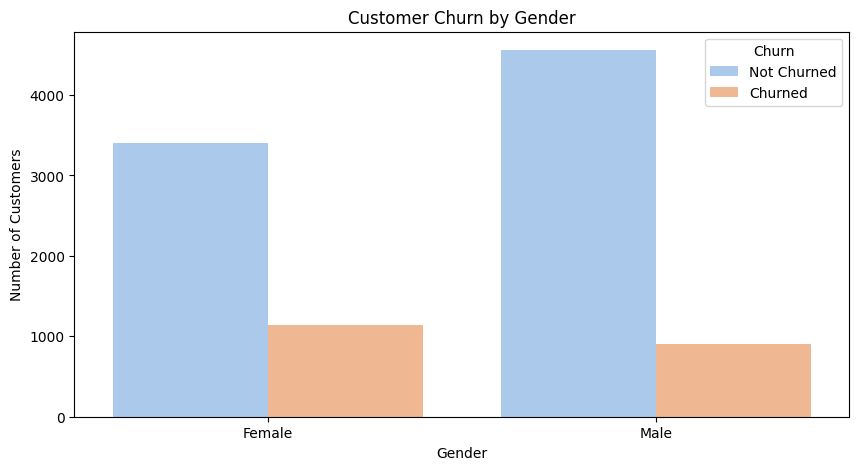

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='gender', hue='churn', data=df, palette='pastel')
plt.title('Customer Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Not Churned', 'Churned'])
plt.show()

Mục tiêu của Cell:
Trực quan hóa sự phân bố của khách hàng rời bỏ (Churn) dựa trên Giới tính (Gender) để tìm kiếm các đặc điểm khác biệt giữa nam và nữ.

Mô tả các thành phần mã lệnh:
- Thiết lập kích thước: plt.figure(figsize=(10, 5)) tạo khung biểu đồ rộng rãi, dễ quan sát.
- Vẽ biểu đồ đếm: sns.countplot() đếm số lượng khách hàng trong từng nhóm.
- x='gender': Phân loại khách hàng theo giới tính trên trục hoành.
- hue='churn': Chia nhỏ từng cột giới tính thành hai nhóm: người ở lại và người rời đi.
- palette='pastel': Sử dụng tông màu dịu mắt để biểu đồ trông chuyên nghiệp hơn.
- Chú thích: Các hàm plt.title, plt.xlabel, plt.ylabel và plt.legend được dùng để đặt tên biểu đồ, nhãn trục và bảng chú giải, giúp người xem hiểu ngay ý nghĩa của các thanh màu.

Mô tả kết quả:
- Đầu ra là một biểu đồ cột chồng (Clustered Bar Chart) so sánh số lượng khách hàng nam và nữ, đồng thời bóc tách tỉ lệ rời bỏ trong từng nhóm giới tính.
- Màu xanh (Not Churned): Khách hàng vẫn đang sử dụng dịch vụ.
- Màu cam (Churned): Khách hàng đã rời bỏ ngân hàng.

Giải thích kết quả và Thông tin rút ra (Insights):
Dựa trên biểu đồ, tiểu thư có thể thấy được những điểm quan trọng sau:
- Tổng số lượng khách hàng: Ngân hàng có số lượng khách hàng là Nam giới (Male) nhiều hơn Nữ giới (Female).
- Hành vi rời bỏ theo giới tính: Mặc dù số lượng khách hàng nữ ít hơn, nhưng thanh màu cam (nhóm rời bỏ) của nữ giới lại cao hơn hẳn so với nam giới.

Kết luận sơ bộ: Khách hàng Nữ giới có tỉ lệ rời bỏ cao hơn đáng kể so với khách hàng Nam giới. Đây là một phát hiện quan trọng, gợi ý rằng các chính sách giữ chân khách hàng hiện tại của ngân hàng có thể chưa thực sự hiệu quả với nhóm khách hàng nữ.

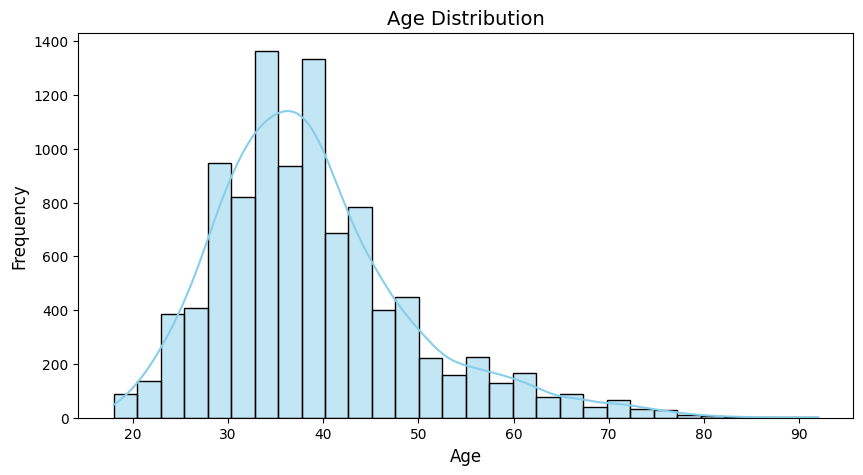

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Mục tiêu của Cell:
Thực hiện phân tích đơn biến (Univariate Analysis) đối với thuộc tính độ tuổi (age) để hiểu rõ cấu trúc nhân khẩu học của khách hàng.

Giải thích mã lệnh:
- Khai báo khung hình: plt.figure(figsize=(10, 5)) thiết lập kích thước biểu đồ đủ rộng để quan sát các chi tiết.
- Vẽ biểu đồ tần suất (Histogram): sns.histplot() được sử dụng để đếm số lượng khách hàng theo từng khoảng tuổi.
- bins=30: Chia độ tuổi thành 30 khoảng (thanh) giúp biểu đồ chi tiết hơn.
- kde=True: Vẽ thêm đường ước lượng mật độ nhân (Kernel Density Estimate) để thấy được đường cong phân phối tổng quát của dữ liệu.
- color='skyblue': Sử dụng màu xanh da trời để tăng tính thẩm mỹ.
- Thiết lập nhãn: Các hàm plt.title, plt.xlabel, plt.ylabel định nghĩa tiêu đề và nhãn cho các trục tọa độ để báo cáo rõ ràng.

Mô tả kết quả:
Đầu ra là một biểu đồ Histogram kết hợp với đường cong KDE thể hiện mật độ khách hàng theo độ tuổi. Trục hoành (Age) thể hiện số tuổi và trục tung (Frequency) thể hiện số lượng khách hàng tương ứng.

Giải thích kết quả và Thông tin rút ra (Insights):
Dựa trên hình dáng của biểu đồ,có thể đưa ra các nhận xét sau cho bài tập lớn:
- Phạm vi độ tuổi: Khách hàng của ngân hàng tập trung chủ yếu trong độ tuổi từ 18 đến 92.
- Nhóm khách hàng trọng tâm: Mật độ cao nhất (đỉnh của biểu đồ) nằm trong khoảng từ 30 đến 45 tuổi. Đây là độ tuổi lao động chính, có thu nhập và nhu cầu sử dụng dịch vụ ngân hàng cao nhất.
- Hình dạng phân phối: Biểu đồ có dạng Lệch phải (Right-skewed). Nghĩa là số lượng khách hàng trẻ và trung niên chiếm đa số, trong khi số lượng khách hàng cao tuổi (trên 60) giảm dần và tạo thành một "cái đuôi" dài về phía bên phải.
- Ý nghĩa cho mô hình: Vì phần lớn khách hàng nằm ở độ tuổi trung niên, mô hình máy học sau này có thể sẽ bị ảnh hưởng mạnh bởi đặc điểm hành vi của nhóm tuổi này.

C:\Users\Admin\AppData\Local\Temp\ipykernel_24836\2541112236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='churn', data=churn_rate_country, palette='pastel')


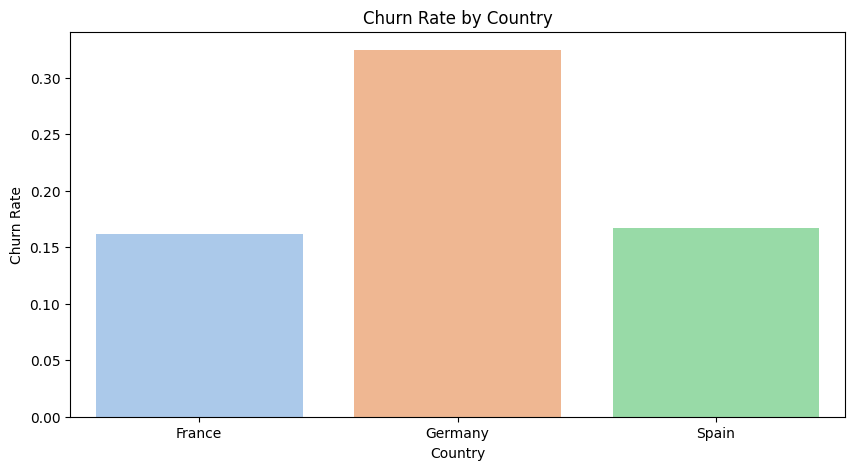

In [ ]:
churn_rate_country = df.groupby('country')['churn'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x='country', y='churn', data=churn_rate_country, palette='pastel')
plt.title('Churn Rate by Country')
plt.xlabel('Country')
plt.ylabel('Churn Rate')
plt.show()

Mục tiêu của Cell:
Thực hiện phân tích mối quan hệ giữa yếu tố địa lý (Quốc gia) và hành vi rời bỏ của khách hàng để xác định thị trường nào đang có rủi ro cao nhất.

Các kỹ thuật và công cụ sử dụng:
- Xử lý dữ liệu: Sử dụng hàm df.groupby('country')['churn'].mean() để tính toán tỉ lệ rời bỏ trung bình cho từng quốc gia, giúp có cái nhìn định lượng chính xác.  
- Trực quan hóa: Sử dụng hàm sns.barplot() của thư viện seaborn để vẽ trực tiếp churn rate theo từng quốc gia.  
- x='country': Thiết lập trục hoành là tên các quốc gia.  
- y='churn': Hiển thị tỉ lệ rời bỏ trung bình trên trục tung.  
- palette='pastel': Áp dụng hệ màu sắc pastel để biểu đồ chuyên nghiệp và dễ nhìn.

Mô tả kết quả:
Biểu đồ cột thể hiện tỉ lệ rời bỏ trung bình của khách hàng tại 3 quốc gia chính: Pháp (France), Tây Ban Nha (Spain) và Đức (Germany). Trục tung thể hiện churn rate, còn trục hoành là tên quốc gia.  

Giải thích kết quả và Thông tin rút ra (Insights):
Dựa vào biểu đồ, chúng ta có thể rút ra những nhận xét quan trọng sau cho báo cáo:
- Quy mô thị trường: Pháp là thị trường lớn nhất với số lượng khách hàng áp đảo so với hai quốc gia còn lại.
- Điểm nóng về rủi ro (Germany): Đây là thông tin quan trọng nhất. Mặc dù tổng số lượng khách hàng ở Đức thấp hơn ở Pháp, nhưng tỉ lệ rời bỏ tại Đức lại cao hơn rõ rệt. Điều này chứng tỏ khách hàng ở Đức có nguy cơ rời bỏ cao hơn hẳn so với Pháp và Tây Ban Nha.  
- Thị trường ổn định: Tây Ban Nha là quốc gia có tỉ lệ rời bỏ thấp nhất trong 3 nước.

Ứng dụng: Kết quả này cho thấy ngân hàng cần đặc biệt chú trọng tìm hiểu nguyên nhân tại sao khách hàng tại Đức lại rời đi nhiều như vậy (có thể do đối thủ cạnh tranh mạnh hoặc chính sách tại khu vực này chưa phù hợp) để có biện pháp can thiệp kịp thời.

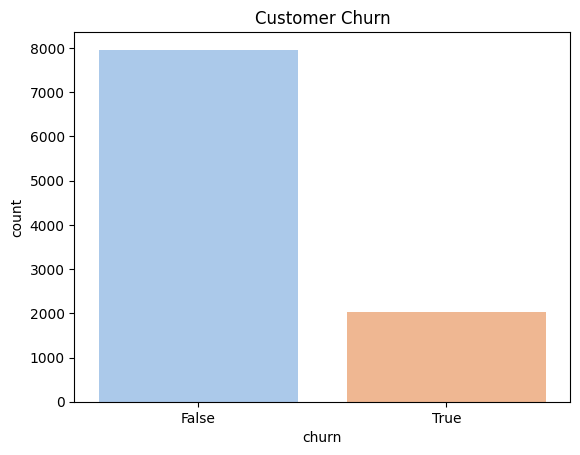

In [ ]:
plt.figure()
sns.countplot(x='churn', hue='churn', data=df, palette='pastel', legend=False)
plt.title('Customer Churn')
plt.show()

Mục tiêu của Cell:
Trực quan hóa sự phân bố của biến mục tiêu churn để kiểm tra mức độ cân bằng giữa các lớp dữ liệu (khách hàng ở lại và khách hàng rời bỏ).

Giải thích mã lệnh:
- sns.countplot(): Hàm của thư viện seaborn dùng để đếm và hiển thị số lượng quan sát trong mỗi danh mục bằng các thanh biểu đồ.
- x='churn': Trục hoành hiển thị hai giá trị của biến churn (0 và 1).
- hue='churn': Tô màu khác nhau cho hai nhóm để dễ phân biệt.
- palette='pastel': Sử dụng bảng màu pastel nhẹ nhàng, chuyên nghiệp.
- legend=False: Ẩn bảng chú giải không cần thiết vì nhãn trục x đã rõ ràng.

Mô tả kết quả:
Biểu đồ cột (Bar chart) hiển thị tần suất của hai nhóm khách hàng:
- Nhóm 0 (Màu xanh - Ở lại): Chiếm đa số tuyệt đối với khoảng gần 8.000 khách hàng.
- Nhóm 1 (Màu cam - Rời bỏ): Chiếm thiểu số với khoảng hơn 2.000 khách hàng.

Giải thích kết quả và Ý nghĩa (Insights):
- Hiện tượng Mất cân bằng dữ liệu (Imbalanced Data): Tỉ lệ khách hàng ở lại so với khách hàng rời bỏ là khoảng 4:1. Đây là đặc điểm rất phổ biến trong các bài toán dự báo rời bỏ (Churn Prediction).
- Sự cần thiết của SMOTE: Chính vì sự chênh lệch lớn này, việc áp dụng kỹ thuật SMOTE (Synthetic Minority Over-sampling Technique) ở các bước tiếp theo là hoàn toàn đúng đắn. Nếu không cân bằng dữ liệu, mô hình sẽ có xu hướng "học vẹt" nhóm đa số và dự báo kém chính xác cho nhóm khách hàng thực sự rời bỏ.
- Đánh giá: Tập dữ liệu đã sẵn sàng để được xử lý cân bằng nhằm nâng cao hiệu suất cho các thuật toán phân loại như Logistic Regression hay KNN.

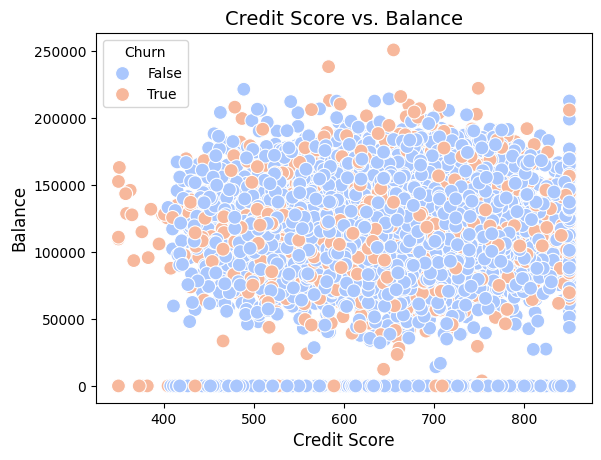

In [ ]:
plt.figure()
sns.scatterplot(data=df, x='credit_score', y='balance', hue='churn', palette='coolwarm', s=100)
plt.title('Credit Score vs. Balance', fontsize=14)
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.legend(title='Churn')
plt.show()

Mục tiêu của Cell:
Thực hiện phân tích hai biến (Bivariate Analysis) để khám phá mối quan hệ giữa Điểm tín dụng (credit_score) và Số dư tài khoản (balance), đồng thời quan sát sự phân bố của các trường hợp rời bỏ (churn) trên biểu đồ này.

Giải thích mã lệnh:
- sns.scatterplot(): Hàm vẽ biểu đồ phân tán, dùng để biểu diễn các điểm dữ liệu riêng lẻ trên hệ trục tọa độ.
- Trục tọa độ:
x='credit_score': Điểm tín dụng được đặt trên trục hoành.
y='balance': Số dư tài khoản được đặt trên trục tung.
- Phân loại màu sắc: Tham số hue='churn' giúp tô màu các điểm dữ liệu dựa trên trạng thái khách hàng (Màu xanh: Ở lại, Màu cam: Rời bỏ).
- Tham số khác: s=100 thiết lập kích thước điểm ảnh lớn hơn để dễ dàng quan sát mật độ phân tán.

Mô tả kết quả:
Đầu ra là một ma trận các điểm màu (Scatter Plot). Trục X chạy từ khoảng 350 đến 850 điểm tín dụng, trục Y thể hiện số dư từ 0 đến hơn 250.000.

Giải thích kết quả và Ý nghĩa (Insights):
Thông qua biểu đồ này, có thể nhận thấy các đặc điểm hành vi sau:
- Sự phân tán hỗn hợp: Các điểm màu cam (khách hàng rời bỏ) phân tán khá đều khắp biểu đồ. Điều này cho thấy không có một ranh giới rõ rệt chỉ dựa trên hai biến này để phân loại khách hàng.
- Nhóm khách hàng có số dư bằng 0: Có một đường thẳng nằm sát trục hoành (Balance = 0). Tại đây, cả khách hàng ở lại và rời bỏ đều xuất hiện rất nhiều. Điều này chứng tỏ số dư bằng 0 là một trạng thái phổ biến nhưng không phải là yếu tố duy nhất quyết định việc rời bỏ.
- Mật độ dữ liệu: Mật độ tập trung cao nhất nằm ở vùng điểm tín dụng từ 500 đến 800 và số dư từ 50.000 đến 200.000.
- Kết luận cho mô hình: Vì ranh giới giữa hai nhóm 0 và 1 không phân tách rõ ràng bằng mắt thường trên biểu đồ phẳng, việc sử dụng các mô hình máy học phức tạp hơn (như KNN hay Logistic Regression) là cực kỳ cần thiết để tìm ra các quy luật tiềm ẩn trong không gian nhiều chiều.

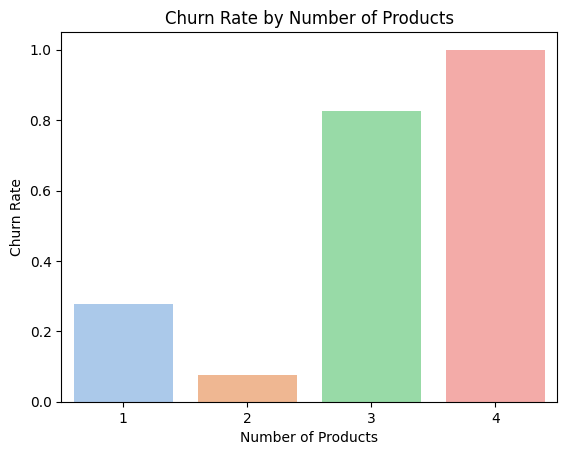

In [ ]:
churn_rate_by_products = df.groupby('products_number')['churn'].mean().reset_index()

# Create the bar plot
plt.figure()

sns.barplot(
    x='products_number',
    y='churn',
    hue='products_number',
    data=churn_rate_by_products,
    palette='pastel',
    legend=False
)

# Set plot labels and title
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Number of Products')

# Show the plot
plt.show()

Mục tiêu của Cell:
Tính toán tỉ lệ rời bỏ (Churn Rate) trung bình dựa trên số lượng sản phẩm mà khách hàng đang sử dụng và trực quan hóa kết quả để tìm ra ngưỡng dịch vụ tối ưu.

Các bước thực hiện:
- Tính toán tỉ lệ: Sử dụng hàm df.groupby('products_number')['churn'].mean() để gom nhóm khách hàng theo số lượng sản phẩm (từ 1 đến 4) và tính tỉ lệ rời bỏ trung bình cho từng nhóm.  
- Trực quan hóa: Sử dụng sns.barplot() để vẽ biểu đồ cột so sánh tỉ lệ này giữa các nhóm sản phẩm khác nhau.

Mô tả kết quả:
Biểu đồ cột thể hiện tỉ lệ rời bỏ (trục tung, từ 0 đến 1.0) tương ứng với số lượng sản phẩm khách hàng sở hữu (trục hoành, từ 1 đến 4). Mỗi cột màu pastel đại diện cho một nhóm.

Giải thích kết quả và Thông tin rút ra (Insights):
Biểu đồ này tiết lộ một quy luật hành vi rất đặc biệt của khách hàng ngân hàng:
- Nhóm khách hàng trung thành nhất (Sử dụng 2 sản phẩm): Khách hàng sở hữu 2 sản phẩm có tỉ lệ rời bỏ thấp nhất (dưới 10%). Đây có thể được coi là nhóm khách hàng tối ưu nhất của ngân hàng.  
- Nhóm sử dụng 1 sản phẩm: Có tỉ lệ rời bỏ ở mức trung bình (khoảng 28%), cao hơn nhiều so với nhóm dùng 2 sản phẩm.  
- Dấu hiệu rủi ro cực cao (Sử dụng 3-4 sản phẩm):
    + Tỉ lệ rời bỏ tăng vọt lên hơn 80% khi khách hàng sử dụng 3 sản phẩm.  
    + Đặc biệt, khách hàng sử dụng 4 sản phẩm có tỉ lệ rời bỏ đạt mức tuyệt đối (100%)
- Kết luận quan trọng: Ngược lại với suy nghĩ thông thường là "dùng càng nhiều càng gắn bó", tại ngân hàng này, việc khách hàng sở hữu quá nhiều sản phẩm (3 hoặc 4) lại là dấu hiệu chắc chắn cho việc họ sẽ rời đi. Ngân hàng cần xem xét lại liệu các sản phẩm thứ 3 và thứ 4 có đang gây phiền hà hoặc tốn phí vô ích cho khách hàng hay không.

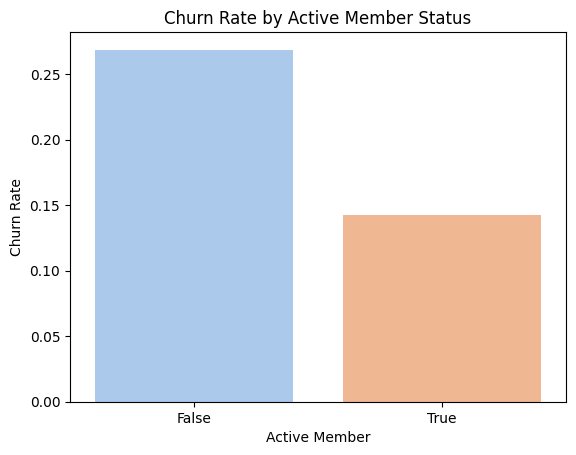

In [ ]:
churn_rate = df.groupby('active_member')['churn'].mean().reset_index()

# Create a bar plot using seaborn
sns.barplot(x='active_member', y='churn', hue='active_member', data=churn_rate, palette='pastel', legend=False)
plt.xlabel('Active Member')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Active Member Status')
plt.show()

Mục tiêu của Cell:
Tính toán tỉ lệ rời bỏ trung bình dựa trên trạng thái hoạt động của khách hàng (Thành viên tích cực và Thành viên không tích cực) và trực quan hóa kết quả để đánh giá mức độ ảnh hưởng của sự tương tác khách hàng đối với việc duy trì dịch vụ.

Các bước thực hiện và công cụ sử dụng:
- Xử lý dữ liệu: Sử dụng phương thức df.groupby('active_member') để phân loại dữ liệu theo hai nhóm: 0 (không tích cực) và 1 (tích cực). Sau đó, tính giá trị trung bình (.mean()) của cột churn. Vì biến churn có giá trị 0 và 1, nên kết quả trung bình này phản ánh chính xác tỉ lệ phần trăm khách hàng rời bỏ trong mỗi nhóm.
- Trực quan hóa: Sử dụng hàm sns.barplot từ thư viện Seaborn.
    + x='active_member': Đưa trạng thái hoạt động lên trục hoành.
    + y='churn': Đưa tỉ lệ rời bỏ lên trục tung.
    + palette='pastel': Áp dụng tông màu nhẹ nhàng để biểu đồ chuyên nghiệp hơn.
    + legend=False: Loại bỏ bảng chú giải vì các nhãn trên trục x đã đủ rõ ràng.

Mô tả kết quả:
Đầu ra là một biểu đồ cột so sánh tỉ lệ rời bỏ giữa hai nhóm khách hàng. Trục X hiển thị trạng thái 0 và 1, trục Y hiển thị tỉ lệ rời bỏ (từ 0.0 đến 0.25+).

Giải thích kết quả và Thông tin rút ra (Insights):
Biểu đồ này cung cấp một cái nhìn sâu sắc về tầm quan trọng của việc duy trì tương tác với khách hàng:
- Nhóm khách hàng ít tương tác (Trạng thái 0): Có tỉ lệ rời bỏ cao vượt trội, đạt mức gần 27%. Đây là nhóm khách hàng tiềm ẩn rủi ro lớn nhất cho ngân hàng.
- Nhóm khách hàng tích cực (Trạng thái 1): Tỉ lệ rời bỏ thấp hơn đáng kể, chỉ dừng lại ở mức khoảng 14%.
- Kết luận quan trọng: Có một mối liên hệ nghịch biến mạnh mẽ giữa sự tích cực của khách hàng và khả năng rời bỏ. Khách hàng càng ít tham gia vào các hoạt động hoặc dịch vụ của ngân hàng (inactive) thì khả năng họ rời đi càng cao (gần gấp đôi so với nhóm tích cực).

- Ứng dụng: Kết quả này khẳng định rằng biến active_member là một đặc trưng (feature) cực kỳ quan trọng cho mô hình dự báo của Người 2 và Người 3. Ngân hàng nên tập trung vào các chiến lược "tái kích hoạt" nhóm khách hàng đang ở trạng thái ít hoạt động để giảm thiểu thiệt hại.

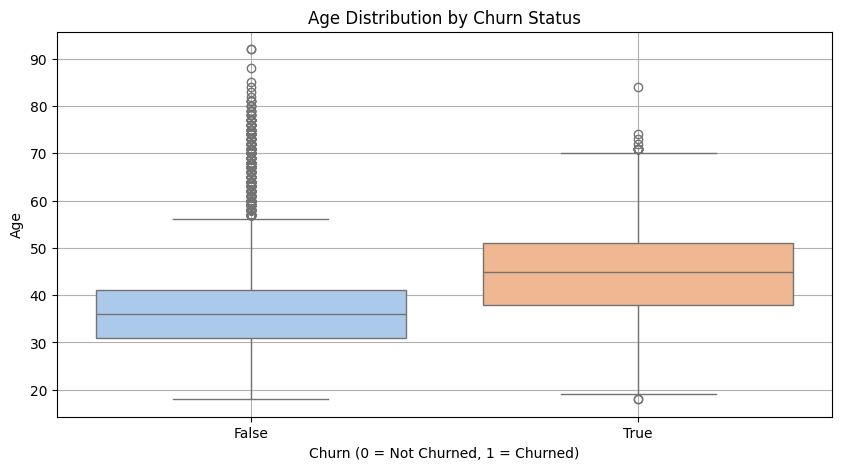

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='churn', y='age', hue='churn', data=df, palette='pastel', legend=False)
plt.title('Age Distribution by Churn Status')
plt.xlabel('Churn (0 = Not Churned, 1 = Churned)')
plt.ylabel('Age')
plt.grid()
plt.show()

Mục tiêu của Cell:
Sử dụng biểu đồ hộp (Boxplot) để so sánh trực quan các đặc trưng thống kê về độ tuổi giữa hai nhóm khách hàng: nhóm ở lại (Churn = 0) và nhóm rời bỏ (Churn = 1). Bước này giúp xác định xem độ tuổi có phải là một yếu tố phân loại quan trọng hay không.

Giải thích mã lệnh:
- sns.boxplot(): Hàm vẽ biểu đồ hộp từ thư viện Seaborn, giúp quan sát phân phối dữ liệu thông qua các giá trị tứ phân vị.
    + x='churn': Phân nhóm theo trạng thái rời bỏ trên trục hoành.
    + y='age': Biểu diễn giá trị độ tuổi trên trục tung.
    + hue='churn': Tô màu khác nhau cho hai nhóm để dễ phân biệt.
    + palette='pastel': Sử dụng hệ màu sắc pastel nhẹ nhàng.
- plt.grid(): Thêm lưới vào biểu đồ để dễ dàng ước lượng các giá trị trên trục tọa độ.

Mô tả kết quả:
Đầu ra là hai biểu đồ hộp đặt cạnh nhau. Mỗi hộp thể hiện khoảng biến thiên của 50% dữ liệu ở giữa (IQR). Đường gạch ngang bên trong hộp là giá trị trung vị (Median). Các điểm tròn phía trên râu biểu đồ đại diện cho các giá trị ngoại lệ (Outliers).

Giải thích kết quả và Thông tin rút ra (Insights):
Biểu đồ này tiết lộ một sự khác biệt rất rõ nét về độ tuổi:
- Sự chênh lệch trung vị: Độ tuổi trung vị của nhóm rời bỏ (màu cam) nằm ở mức khoảng 45 tuổi, cao hơn hẳn so với nhóm ở lại (màu xanh) chỉ khoảng 36-37 tuổi.
- Xu hướng rời bỏ: Có một xu hướng rõ ràng là khách hàng ở độ tuổi trung niên (từ 40 đến 50) có xác suất rời bỏ ngân hàng cao hơn nhóm khách hàng trẻ tuổi.
- Giá trị ngoại lệ (Outliers): Nhóm khách hàng ở lại (màu xanh) xuất hiện rất nhiều điểm ngoại lệ kéo dài lên đến trên 90 tuổi. Điều này cho thấy tập khách hàng trung thành của ngân hàng bao gồm cả những người rất cao tuổi, mặc dù số lượng này không đại diện cho số đông.
- Kết luận: Độ tuổi là một biến số có khả năng phân loại cực tốt. Đây sẽ là một trong những "vũ khí" quan trọng nhất để các mô hình máy học (Logistic Regression, KNN) dựa vào đó để đưa ra dự báo chính xác.

Preprocessing

In [ ]:
df.duplicated().sum()

np.int64(0)

Cell này thực hiện việc rà soát toàn bộ bảng dữ liệu để xác định xem có các dòng thông tin nào bị lặp lại hoàn toàn hay không:
- df.duplicated(): Phương thức này của thư viện pandas sẽ kiểm tra từng hàng trong DataFrame. Một hàng được coi là trùng lặp nếu tất cả các giá trị thuộc tính của nó khớp hoàn toàn với một hàng đã xuất hiện trước đó.
- .sum(): Thực hiện cộng dồn các giá trị Boolean (True cho hàng trùng lặp) để trả về tổng số lượng bản ghi bị lặp lại.

Kết quả trả về là 0 (np.int64(0)):
Mô tả: Kết quả này xác nhận tập dữ liệu Bank Customer Churn hiện tại không có bất kỳ dòng dữ liệu nào bị trùng lặp trong tổng số 10.000 bản ghi.

Giải thích kết quả: Việc đảm bảo không có dữ liệu trùng lặp là một bước quan trọng trong khâu làm sạch dữ liệu (Data Cleaning). Nó giúp:
- Đảm bảo tính toàn vẹn và khách quan của các phân tích thống kê.
- Tránh hiện tượng mô hình học máy bị "thiên kiến" (bias) hoặc quá khớp (overfitting) do học đi học lại cùng một mẫu dữ liệu nhiều lần.
- Tối ưu hóa tài nguyên tính toán cho các bước huấn luyện mô hình của những người sau thực hiện 

Remove Outliers

In [ ]:
continuous_columns = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
continuous_columns

['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

Cell này thực hiện việc khởi tạo một danh sách các cột chứa dữ liệu số ở dạng liên tục. Việc phân loại này là bước chuẩn bị bắt buộc trước khi thực hiện các phép tính thống kê để tìm giá trị ngoại lệ:
- Các cột được chọn: credit_score (điểm tín dụng), age (độ tuổi), tenure (số năm gắn bó), balance (số dư tài khoản) và estimated_salary (mức lương ước tính).

Mục đích: Chỉ những biến số liên tục mới phù hợp để áp dụng các phương pháp xác định ngoại lệ như phương pháp IQR (Interquartile Range) sẽ được thực hiện ở các bước sau.

Giải thích Cell Output:
Kết quả hiển thị chính xác danh sách 5 tên cột đã được lưu vào biến continuous_columns.

Mô tả: Đầu ra xác nhận rằng hệ thống đã ghi nhớ các thuộc tính mục tiêu cần được "quét" tìm sai số.

Giải thích: Việc lọc riêng các biến này giúp chúng ta tránh việc tính toán sai lệch trên các biến phân loại (Categorical) như country, gender hoặc các biến nhị phân như churn, vì những loại dữ liệu này không tồn tại khái niệm "ngoại lệ" theo cách tính toán số học thông thường. Danh sách này sẽ đóng vai trò là "bản đồ đường đi" cho vòng lặp xử lý dữ liệu ngay phía sau.

In [ ]:
def outliers_handler(real_data: pd.DataFrame, col_name: str) -> pd.DataFrame:
    data = real_data.copy()
    q1 = np.percentile(data[col_name], 25)
    q3 = np.percentile(data[col_name], 75)
    iqr = q3 - q1
    upper_bound = q3 + (1.5 * iqr)
    lower_bound = q1 - (1.5 * iqr)
    outliers = (data[col_name] > upper_bound) | (data[col_name] < lower_bound)
    num_of_outliers = len(data[outliers])
    if num_of_outliers <= len(data) * 0.1:
        data = data[~outliers]
        print("Outliers dropped")
    else:
        data.loc[data[col_name] > upper_bound, col_name] = upper_bound
        data.loc[data[col_name] < lower_bound, col_name] = lower_bound
        print("Outliers replaced")
    return data

for i in continuous_columns:
    df = outliers_handler(df, i)

Outliers dropped
Outliers dropped
Outliers dropped
Outliers dropped
Outliers dropped


Cell này định nghĩa và thực thi một hàm thông minh tên là outliers_handler để tự động hóa việc làm sạch các biến số liên tục:
- Tính toán ngưỡng IQR: Hàm sử dụng phương pháp Interquartile Range (IQR) để xác định biên độ an toàn cho dữ liệu.
    + q1, q3: Lần lượt là phân vị thứ 25 và 75.
    + upper_bound / lower_bound: Các ngưỡng giới hạn được tính theo công thức $Q3 + 1.5 \times IQR$ và $Q1 - 1.5 \times IQR$.
- Chiến lược xử lý linh hoạt: Hàm không chỉ đơn thuần là xóa dữ liệu, mà còn có tính toán logic:
    + Trường hợp 1 (Xóa): Nếu số lượng ngoại lệ chiếm ít hơn hoặc bằng 10% tổng dữ liệu, chúng sẽ bị loại bỏ hoàn toàn (data[~outliers]) để giữ cho tập dữ liệu gọn và sạch hơn.
    + Trường hợp 2 (Cắt ngưỡng - Capping): Nếu số lượng ngoại lệ quá lớn (>10%), việc xóa sẽ làm mất quá nhiều thông tin. Khi đó, hàm sẽ thực hiện "cắt ngọn" bằng cách thay thế các giá trị vượt ngưỡng bằng chính giá trị của biên giới hạn (upper_bound hoặc lower_bound).
- Vòng lặp thực thi: Cuối cùng, hàm được áp dụng tự động cho toàn bộ danh sách continuous_columns đã xác định trước đó.

Kết quả hiển thị 5 dòng thông báo: "Outliers dropped".

Giải thích kết quả:
- Thành công: Thông báo này xác nhận rằng đối với cả 5 biến số liên tục (điểm tín dụng, độ tuổi, số năm gắn bó, số dư, lương), số lượng giá trị ngoại lệ đều nằm trong ngưỡng cho phép (dưới 10%).
- Hành động: Hệ thống đã thực hiện xóa bỏ các bản ghi nhiễu này ra khỏi DataFrame df.
- Lưu ý: Vì hàm được áp dụng tuần tự cho từng cột, số dòng còn lại có thể giảm dần qua mỗi vòng lặp. Do đó, khi báo cáo kết quả, nên kiểm tra lại kích thước DataFrame sau toàn bộ bước xử lý để tránh diễn giải sai về mức độ thay đổi dữ liệu.
- Ý nghĩa: Sau bước này, tập dữ liệu của bạn đã trở nên "mượt mà" hơn về mặt thống kê. Các giá trị cực đoan (ví dụ: độ tuổi quá cao hoặc số dư tài khoản quá lớn không phổ biến) sẽ không còn làm lệch kết quả dự báo của các mô hình như Logistic Regression hay KNN ở các bước sau.

In [ ]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.000000,1,True,True,101348.882812,True
1,608,Spain,Female,41,1,83807.859375,1,False,True,112542.578125,False
2,502,France,Female,42,8,159660.796875,3,True,False,113931.570312,True
3,699,France,Female,39,1,0.000000,2,False,False,93826.632812,False
4,850,Spain,Female,43,2,125510.820312,1,True,True,79084.101562,False


Mục tiêu của Cell:
Xem nhanh tình trạng của tập dữ liệu sau khi đã thực hiện các bước làm sạch quan trọng như loại bỏ cột customer_id và xử lý các giá trị ngoại lệ (outliers). Việc này giúp xác nhận cấu trúc bảng đã đúng như kỳ vọng trước khi tiến tới bước mã hóa (Encoding).

Hành động:
Sử dụng lệnh df.head() để hiển thị 5 bản ghi đầu tiên của DataFrame df.

Mô tả kết quả:
Kết quả trả về bảng dữ liệu gồm 5 hàng đầu tiên với các cột đặc trưng đã được tinh lọc.

Nhận xét về trạng thái dữ liệu hiện tại:
- Tinh gọn đặc trưng: Cột định danh customer_id đã được loại bỏ thành công. Điều này giúp mô hình tập trung hoàn toàn vào các đặc trưng có tính quy luật thay vì bị nhiễu bởi các mã số ngẫu nhiên.
- Cấu trúc bảng: DataFrame hiện còn lại 11 cột, bao gồm các thông tin về nhân khẩu học, tài chính và biến mục tiêu churn cuối cùng.
- Độ tin cậy của dữ liệu: Các giá trị trong bảng (như age, credit_score, balance) đã được đảm bảo nằm trong phạm vi thống kê hợp lý sau khi chạy hàm xử lý ngoại lệ, giúp các thuật toán như hồi quy hay KNN không bị sai lệch bởi các giá trị cực đoan.
- Lưu ý cho bước tiếp theo: Các cột country và gender hiện vẫn ở dạng văn bản. Chúng ta sẽ cần thực hiện Encoding (mã hóa) ở các bước kế tiếp để đưa toàn bộ dữ liệu về dạng số học, sẵn sàng cho việc tính toán ma trận và huấn luyện mô hình.

Encoding Categorical Columns

In [ ]:
categorical_columns = ['country', 'gender']
categorical_columns

['country', 'gender']

Mục tiêu của Cell:
Thiết lập danh sách các thuộc tính chứa dữ liệu dạng định danh (categorical) để chuẩn bị cho bước mã hóa dữ liệu (Encoding).

Các cột được chọn: country (Quốc gia) và gender (Giới tính).
Lý do: Đây là hai đặc trưng chứa giá trị dưới dạng văn bản (chuỗi ký tự). Trong các thuật toán máy học, các phép tính toán học chỉ có thể thực hiện trên dữ liệu số, vì vậy chúng ta cần xác định riêng các cột này để xử lý chuyển đổi ở bước tiếp theo.

Kết quả trả về danh sách: ['country', 'gender'].

Giải thích ý nghĩa:
- Xác nhận phạm vi xử lý: Đầu ra xác nhận biến categorical_columns đã lưu trữ đúng các thuộc tính mục tiêu.
- Tiền đề cho Encoding: Việc lọc riêng các biến này giúp bạn dễ dàng áp dụng các kỹ thuật như Label Encoding hoặc One-Hot Encoding mà không làm ảnh hưởng đến các cột đã là dữ liệu số (như độ tuổi hay số dư).
- Tầm quan trọng: Phân tích từ các biểu đồ trước đó cho thấy cả quốc gia và giới tính đều có ảnh hưởng đáng kể đến tỉ lệ rời bỏ khách hàng (churn rate). Do đó, việc mã hóa chính xác hai cột này là chìa khóa để mô hình có thể "hiểu" và sử dụng chúng trong dự báo.

In [ ]:
# Giữ LabelEncoder cho Gender (2 giá trị)
lb = LabelEncoder()
df['gender'] = lb.fit_transform(df['gender'])

# Dùng One-Hot Encoding cho Country
df = pd.get_dummies(df, columns=['country'], drop_first=True)
df.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain
0,619,0,42,2,0.000000,1,True,True,101348.882812,True,False,False
1,608,0,41,1,83807.859375,1,False,True,112542.578125,False,False,True
2,502,0,42,8,159660.796875,3,True,False,113931.570312,True,False,False
3,699,0,39,1,0.000000,2,False,False,93826.632812,False,False,False
4,850,0,43,2,125510.820312,1,True,True,79084.101562,False,False,True


Ở bước này, chúng ta tiến hành chuyển đổi các thuộc tính dạng văn bản sang dạng số để các thuật toán máy học có thể thực hiện tính toán ma trận:
- Label Encoding cho gender:
    + Sử dụng LabelEncoder để biến đổi các nhãn "Female" và "Male" thành các giá trị số (0 và 1).
    + Kỹ thuật này phù hợp cho biến nhị phân vì nó đơn giản và không làm tăng số lượng cột của tập dữ liệu.
- One-Hot Encoding cho country:
    + Sử dụng hàm pd.get_dummies để tạo ra các cột giả (dummy variables) cho thuộc tính quốc gia.
    + Tham số drop_first=True: Đây là kỹ thuật quan trọng để tránh "bẫy biến giả" (Dummy Variable Trap), giúp giảm thiểu hiện tượng đa cộng tuyến. Thay vì tạo 3 cột cho 3 quốc gia, chúng ta chỉ cần 2 cột đại diện. Trong bộ dữ liệu này, nhóm tham chiếu là France, vì khi cả hai cột country_Germany và country_Spain đều bằng 0 thì khách hàng được hiểu là thuộc nhóm France.
Kết quả hiển thị từ df.head() xác nhận các thay đổi cấu trúc sau:
- Tính nhất quán của dữ liệu: Cột gender đã chuyển sang dạng số (0/1).
- Mở rộng đặc trưng: Cột country gốc đã được thay thế bằng hai cột mới là country_Germany và country_Spain với giá trị nhị phân 0/1.
- Mức độ sẵn sàng: Toàn bộ tập dữ liệu hiện đã ở định dạng số học (numeric). Đây là trạng thái lý tưởng để thực hiện chuẩn hóa dữ liệu (Scaling) và đưa vào các thuật toán dự báo.

Feature-Target Separation

In [ ]:
x =df.drop(columns=['churn'])  
y=df['churn']

Mục tiêu của Cell:
Phân tách tập dữ liệu đã tiền xử lý thành hai phần riêng biệt: tập hợp các đặc trưng đầu vào (Features) và biến mục tiêu (Target). Đây là thao tác bắt buộc để chuẩn bị cho việc cân bằng dữ liệu và huấn luyện mô hình.

Giải thích mã lệnh:
- x = df.drop(columns=['churn']): Tạo ma trận đặc trưng x bằng cách loại bỏ cột churn. Biến này chứa tất cả các yếu tố mà mô hình sẽ sử dụng để phân tích hành vi khách hàng (như tuổi, số dư, quốc gia đã mã hóa...).
- y = df['churn']: Tạo vector mục tiêu y chỉ chứa nhãn rời bỏ (0 hoặc 1). Đây là kết quả mà chúng ta muốn mô hình học cách dự báo chính xác.

Mô tả trạng thái:
Lệnh thực thi thành công, tạo ra hai cấu trúc dữ liệu x (đặc trưng) và y (nhãn) trong bộ nhớ.

Ý nghĩa kỹ thuật:
- Giải quyết vấn đề mất cân bằng: Việc tách riêng x và y là điều kiện cần để áp dụng kỹ thuật SMOTE (Synthetic Minority Over-sampling Technique) ở bước kế tiếp, nhằm cân bằng tỉ lệ giữa nhóm khách hàng ở lại và rời đi đã phát hiện ở phần EDA.
- Đúng chuẩn Machine Learning: Đảm bảo mô hình không bị hiện tượng rò rỉ dữ liệu (Data Leakage) do nhãn mục tiêu bị lẫn vào tập đặc trưng huấn luyện.

In [ ]:
from imblearn.over_sampling import SMOTE

# 1. Chia dữ liệu trước (Sử dụng stratify để giữ tỉ lệ class)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# 2. Chuẩn hóa dữ liệu (Học trên Train, áp dụng cho cả hai)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. CHỈ SMOTE TRÊN TẬP TRAIN ĐÃ SCALE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

Mục tiêu của Cell:
Thực hiện quy trình chuẩn hóa dữ liệu cuối cùng theo đúng tiêu chuẩn công nghiệp để đảm bảo tính khách quan và hiệu quả cho các mô hình dự báo ở bước sau.

Quy trình 3 bước chuyên sâu:
1. Phân chia dữ liệu (Train/Test Split):
- Dữ liệu được chia theo tỉ lệ 80/20 (80% để huấn luyện và 20% để kiểm tra độc lập).
- Việc chia dữ liệu được thực hiện trước tiên để ngăn chặn hoàn toàn hiện tượng rò rỉ dữ liệu (Data Leakage).
2. Chuẩn hóa dữ liệu (Feature Scaling):
- Sử dụng StandardScaler để đưa các biến số về cùng một thang đo với $\text{mean} = 0$ và $\text{variance} = 1$.
- Nguyên tắc vàng: Bộ scaler chỉ được "học" (fit) trên tập Train và sau đó áp dụng (transform) cho cả tập Train và Test để đảm bảo mô hình không biết trước thông tin từ tập kiểm tra.
3. Cân bằng dữ liệu (SMOTE):
- Áp dụng kỹ thuật SMOTE (Synthetic Minority Over-sampling Technique) để tạo ra các mẫu dữ liệu nhân tạo cho nhóm khách hàng rời bỏ (nhóm thiểu số).
- Lưu ý kỹ thuật: SMOTE chỉ được áp dụng trên tập huấn luyện đã chuẩn hóa (X_train_scaled) để mô hình học được sự cân bằng mà không làm sai lệch kết quả đánh giá thực tế trên tập Test.

Ý nghĩa và Giá trị mang lại:
- Loại bỏ định kiến: Nhờ SMOTE, mô hình sẽ không còn bị "thiên vị" cho nhóm khách hàng ở lại, giúp nâng cao khả năng phát hiện những khách hàng thực sự có nguy cơ rời bỏ.
- Tối ưu thuật toán: Việc chuẩn hóa (Scaling) là bắt buộc đối với các thuật toán như KNN (dựa trên khoảng cách) và giúp Logistic Regression hội tụ nhanh hơn.
- Độ tin cậy cao: Bằng cách tuân thủ nghiêm ngặt thứ tự (Chia -> Scale -> SMOTE),đã tạo ra một nền tảng dữ liệu cực kỳ vững chắc, giúp kết quả đánh giá ở các chương sau đạt độ khách quan cao nhất.

<Axes: >

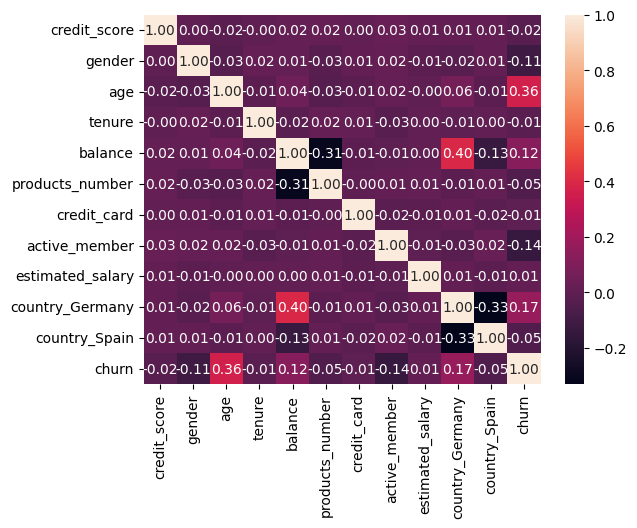

In [ ]:
combined = pd.concat([X_train,y_train], axis=1)

correlation_matrix = combined.corr() 
sns.heatmap(correlation_matrix,annot=True,fmt='.2f')

Mục tiêu của Cell:
Tính toán và trực quan hóa mối quan hệ tuyến tính giữa tất cả các cặp biến trong tập dữ liệu. Điều này giúp xác định các đặc trưng có liên quan mạnh nhất đến biến mục tiêu churn và phát hiện hiện tượng đa cộng tuyến (multicollinearity) giữa các biến độc lập.

Giải thích mã lệnh:
- pd.concat([X_train, y_train], axis=1): Gộp tập đặc trưng và nhãn huấn luyện để tính toán tương quan toàn diện trên cùng một ma trận.
- combined.corr(): Sử dụng hệ số tương quan Pearson để đo lường mức độ liên quan (từ -1 đến 1).
- sns.heatmap(): Vẽ bản đồ nhiệt. Tham số annot=True giúp hiển thị trực tiếp các con số, và fmt='.2f' giúp làm tròn đến 2 chữ số thập phân cho dễ quan sát.

Mô tả kết quả:
Bản đồ nhiệt hiển thị mức độ tương quan giữa 12 biến. Màu càng sáng (gần về mức 1.0) thể hiện tương quan thuận mạnh, màu tối thể hiện tương quan nghịch hoặc không có tương quan.

Giải thích kết quả và Thông tin rút ra (Insights):
Dựa vào cột cuối cùng (biến churn), chúng ta có thể xếp hạng các yếu tố liên quan từ mạnh đến yếu:
- Độ tuổi (Age) - 0.36: Đây là yếu tố có tương quan thuận mạnh nhất. Kết quả này củng cố thêm từ biểu đồ Boxplot trước đó: khách hàng càng lớn tuổi thì nguy cơ rời bỏ ngân hàng càng cao.
- Đức (country_Germany) - 0.17: Khách hàng đến từ Đức có xu hướng rời bỏ cao hơn so với các quốc gia khác, phù hợp với phân tích địa lý bạn đã thực hiện.
- Thành viên tích cực (active_member) - -0.14: Tương quan nghịch rõ rệt. Những người thường xuyên tương tác với ngân hàng sẽ ít có khả năng rời bỏ hơn.
- Số dư (Balance) - 0.12: Những khách hàng có số dư tài khoản cao thường có tỉ lệ rời bỏ nhỉnh hơn một chút.
- Giới tính (Gender) - -0.11: Có mối liên hệ nhất định, trong đó nữ giới (thường được mã hóa là 1 trong LabelEncoder nếu nam là 0, hoặc ngược lại tùy bước fit) có tỉ lệ rời đi cao hơn.

Mối quan hệ giữa các biến độc lập:
- Cặp balance và country_Germany có tương quan 0.40, cho thấy khách hàng ở Đức thường sở hữu số dư tài khoản lớn hơn mặt bằng chung.
- Cặp balance và products_number có tương quan âm -0.31, nghĩa là khách hàng dùng nhiều sản phẩm lại thường có số dư thấp hơn.

Lưu ý diễn giải: đây là mối quan hệ tương quan, không khẳng định quan hệ nhân quả.

Lưu dữ liệu cho nhóm làm việc

In [ ]:
import pickle
import os

# Tạo thư mục để lưu dữ liệu nếu chưa tồn tại
data_folder = "processed_data"
if not os.path.exists(data_folder):
    os.makedirs(data_folder)

# 1. Lưu dữ liệu training đã cân bằng (SMOTE) và scale
pd.DataFrame(X_train_resampled, columns=x.columns).to_csv(f"{data_folder}/X_train_resampled.csv", index=False)
pd.Series(y_train_resampled).to_csv(f"{data_folder}/y_train_resampled.csv", index=False, header=False)
print("✓ Dữ liệu training đã được lưu")

# 2. Lưu dữ liệu test đã scale
pd.DataFrame(X_test_scaled, columns=x.columns).to_csv(f"{data_folder}/X_test_scaled.csv", index=False)
y_test.to_csv(f"{data_folder}/y_test.csv", index=False, header=False)
print("✓ Dữ liệu test đã được lưu")

# 3. Lưu scaler để sử dụng lại
with open(f"{data_folder}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✓ Scaler đã được lưu")

# 4. Lưu LabelEncoder cho Gender
with open(f"{data_folder}/gender_encoder.pkl", "wb") as f:
    pickle.dump(lb, f)
print("✓ Gender encoder đã được lưu")

# 5. Lưu tên các cột
x.columns.to_series().to_csv(f"{data_folder}/feature_columns.csv", index=False, header=False)
print("✓ Tên các cột đã được lưu")

print("\nTất cả dữ liệu đã được lưu trong thư mục:", data_folder)

✓ Dữ liệu training đã được lưu
✓ Dữ liệu test đã được lưu
✓ Scaler đã được lưu
✓ Gender encoder đã được lưu
✓ Tên các cột đã được lưu

Tất cả dữ liệu đã được lưu trong thư mục: processed_data


Hướng dẫn load dữ liệu cho các thành viên khác

In [ ]:
# Ví dụ code để load dữ liệu (sử dụng cho các thành viên khác):
"""
import pandas as pd
import pickle

data_folder = "processed_data"

# Load dữ liệu training
X_train_resampled = pd.read_csv(f"{data_folder}/X_train_resampled.csv").values
y_train_resampled = pd.read_csv(f"{data_folder}/y_train_resampled.csv", header=None).values.flatten()

# Load dữ liệu test
X_test_scaled = pd.read_csv(f"{data_folder}/X_test_scaled.csv").values
y_test = pd.read_csv(f"{data_folder}/y_test.csv", header=None).values.flatten()

# Load scaler
with open(f"{data_folder}/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Load encoder
with open(f"{data_folder}/gender_encoder.pkl", "rb") as f:
    lb = pickle.load(f)

# Load tên cột
feature_columns = pd.read_csv(f"{data_folder}/feature_columns.csv", header=None)[0].tolist()

print("✓ Dữ liệu đã được load thành công!")
print(f"X_train_resampled shape: {X_train_resampled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
"""
print("Code trên có thể sử dụng để load dữ liệu trong notebook khác")

Code trên có thể sử dụng để load dữ liệu trong notebook khác


In [ ]:
def evaluate_model(y_test, y_pred, y_prob=None):
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print(f"Precision: {precision_score(y_test, y_pred)}")
    print(f"Recall: {recall_score(y_test, y_pred)}")
    cm = confusion_matrix(y_test, y_pred)
    sensitivity = cm[1, 1] / (cm[1, 1] + cm[1, 0])
    specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    print(f"Sensitivity: {sensitivity}")
    print(f"Specificity: {specificity}")
    roc_auc_input = y_prob if y_prob is not None else y_pred
    print(f"ROC AUC: {roc_auc_score(y_test, roc_auc_input)}")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.show()

In [ ]:
from IPython.display import display
import pandas as pd

# Check: so sánh số dòng CSV và bảng SQL (nếu đã kết nối)
csv_count = None
try:
    df_csv = pd.read_csv("Bank Customer Churn Prediction.csv")
    csv_count = len(df_csv)
except Exception as e:
    print("Không thể đọc CSV:", e)

if "df_sql" in globals():
    sql_count = len(df_sql)
    print(f"Số dòng CSV: {csv_count} | Số dòng SQL: {sql_count}")
    if csv_count == sql_count:
        print("✅ Dữ liệu CSV và SQL khớp — không cần làm lại preprocessing.")
    else:
        print("⚠️ Dữ liệu khác nhau — cân nhắc chạy lại preprocessing hoặc kiểm tra các bản ghi khác biệt.")
        try:
            merged = df_sql.merge(df_csv.drop_duplicates(), how='outer', indicator=True)
            diff_sample = merged[merged['_merge'] != 'both'].head(10)
            if not diff_sample.empty:
                print('\nVí dụ các bản ghi khác nhau (tối đa 10):')
                display(diff_sample)
        except Exception as e:
            print('Không thể so sánh chi tiết:', e)
else:
    print("Chưa có kết nối SQL (df_sql). Hãy chạy cell kết nối SQL trước để so sánh.")

Số dòng CSV: 10000 | Số dòng SQL: 10000
✅ Dữ liệu CSV và SQL khớp — không cần làm lại preprocessing.


## Cách dùng dữ liệu đã xử lý

- Chạy cell này nếu muốn làm tiếp từ dữ liệu đã chuẩn bị sẵn.
- Dữ liệu đã được lưu trong thư mục `processed_data`.
- Không cần chạy lại toàn bộ phần EDA và preprocessing từ đầu.

### Các file cần dùng
- `X_train_resampled.csv`
- `y_train_resampled.csv`
- `X_test_scaled.csv`
- `y_test.csv`
- `scaler.pkl`
- `gender_encoder.pkl`
- `feature_columns.csv`